<a href="https://colab.research.google.com/github/correctchemist/Systematic-Data-Collection-and-Curation/blob/main/03_09_2025_ExtraTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
dataset = pd.read_csv('//content/oversampling_KlekotaRothCount.csv')
dataset

,Name,KRFPC1,KRFPC14,KRFPC20,KRFPC91,KRFPC126,KRFPC133,KRFPC138,KRFPC161,KRFPC297,...,KRFPC4777,KRFPC4778,KRFPC4810,KRFPC4811,KRFPC4813,KRFPC4820,KRFPC4833,KRFPC4834,KRFPC4843,pIC50
0,MB2,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,4.759950
1,MB4,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,4.729554
2,MB7,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,4.935168
3,MB10,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,4.886725
4,MB13,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,4.856361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,MB381,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,7.154902
247,MB382,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,6.397940
248,MB383,3,0,0,0,1,1,0,0,3,...,0,0,0,0,0,0,0,0,0,4.928118
249,MB388,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,4.931814


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

# Suppress divide-by-zero VIF warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Define Features and Target ---
X = dataset.drop(['pIC50', 'Name'], axis=1)
Y = dataset['pIC50']
names = dataset['Name']

# --- 2. Remove Low-Variance Features ---
def remove_low_variance(input_data, threshold=0.1):
    selector = VarianceThreshold(threshold)
    selector.fit(input_data)
    return input_data[input_data.columns[selector.get_support(indices=True)]]

X = remove_low_variance(X, threshold=0.1)

# --- 3. VIF Calculation and Filtering ---
def calculate_vif(X):
    X_array = X.values
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X_array, i) for i in range(X_array.shape[1])]
    return vif_data

# Iteratively remove features with VIF > 10
max_vif = 10
while True:
    vif_df = calculate_vif(X)
    max_vif_value = vif_df['VIF'].max()
    if max_vif_value > max_vif:
        drop_feature = vif_df.loc[vif_df['VIF'] == max_vif_value, 'Feature'].values[0]
        print(f"Dropping '{drop_feature}' with VIF = {max_vif_value:.2f}")
        X = X.drop(columns=[drop_feature])
    else:
        break

# Save VIF summary and final feature set
vif_df = calculate_vif(X)
vif_df.to_csv("final_vif_features.csv", index=False)
X.to_csv("cleaned_descriptors.csv", index=False)

print("\nFinal VIF Summary:")
print(vif_df)
print(f"\nTotal features remaining after VIF filtering: {X.shape[1]}")


Dropping 'KRFPC161' with VIF = inf
Dropping 'KRFPC383' with VIF = inf
Dropping 'KRFPC1148' with VIF = inf
Dropping 'KRFPC1193' with VIF = inf
Dropping 'KRFPC2259' with VIF = inf
Dropping 'KRFPC2260' with VIF = inf
Dropping 'KRFPC2380' with VIF = inf
Dropping 'KRFPC3010' with VIF = inf
Dropping 'KRFPC3279' with VIF = inf
Dropping 'KRFPC3281' with VIF = inf
Dropping 'KRFPC3285' with VIF = inf
Dropping 'KRFPC3999' with VIF = inf
Dropping 'KRFPC3058' with VIF = 114896.37
Dropping 'KRFPC2975' with VIF = 19525.92
Dropping 'KRFPC4000' with VIF = 16869.19
Dropping 'KRFPC3224' with VIF = 11124.68
Dropping 'KRFPC3643' with VIF = 7104.97
Dropping 'KRFPC3751' with VIF = 4831.88
Dropping 'KRFPC3956' with VIF = 2482.94
Dropping 'KRFPC2547' with VIF = 1979.48
Dropping 'KRFPC3440' with VIF = 1504.06
Dropping 'KRFPC3659' with VIF = 1243.92
Dropping 'KRFPC4005' with VIF = 1167.07
Dropping 'KRFPC3640' with VIF = 1158.82
Dropping 'KRFPC3882' with VIF = 964.54
Dropping 'KRFPC3692' with VIF = 585.84
Droppin

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the cleaned descriptors (features only)
X = pd.read_csv("cleaned_descriptors.csv")

# 2. Load the original dataset to retrieve 'pIC50' and 'Name'
original_data = pd.read_csv("/content/oversampling_KlekotaRothCount.csv")  # Replace with actual file name

# 3. Match the rows by index and extract 'pIC50' and 'Name'
Y = original_data.loc[X.index, 'pIC50']
names = original_data.loc[X.index, 'Name']

# 4. Split the dataset into training and test sets (70/30)
X_train, X_test, Y_train, Y_test, names_train, names_test = train_test_split(
    X, Y, names, test_size=0.3, random_state=42
)

# Optional: confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (175, 39)
X_test shape: (76, 39)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the cleaned descriptors (features only)
X = pd.read_csv("cleaned_descriptors.csv")

# 2. Load the original dataset to retrieve 'pIC50' and 'Name'
original_data = pd.read_csv("/content/oversampling_KlekotaRothCount.csv")  # Update path if needed

# 3. Match the rows by index and extract 'pIC50' and 'Name'
Y = original_data.loc[X.index, 'pIC50']
names = original_data.loc[X.index, 'Name']

# 4. Split the dataset into training and test sets (70/30)
X_train, X_test, Y_train, Y_test, names_train, names_test = train_test_split(
    X, Y, names, test_size=0.3, random_state=42
)

# 5. Save training and test sets to CSV
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
Y_train.to_csv("Y_train.csv", index=False)
Y_test.to_csv("Y_test.csv", index=False)
names_train.to_csv("names_train.csv", index=False)
names_test.to_csv("names_test.csv", index=False)

# 6. Optional: confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (175, 39)
X_test shape: (76, 39)


In [ ]:
# Train the ExtraTrees model
model = ExtraTreesRegressor(n_estimators=500, random_state=42)
model.fit(X_train, Y_train)

ExtraTreesRegressor(n_estimators=500, random_state=42)

In [ ]:
# Predict for train and test sets
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)


In [ ]:
# Calculate metrics
print('Train MSE: %.2f' % mean_squared_error(Y_train, Y_train_pred))
print('Train R^2: %.2f' % r2_score(Y_train, Y_train_pred))
print('Test MSE: %.2f' % mean_squared_error(Y_test, Y_test_pred))
print('Test R^2: %.2f' % r2_score(Y_test, Y_test_pred))

Train MSE: 0.00
Train R^2: 1.00
Test MSE: 0.25
Test R^2: 0.78


In [ ]:
import pickle

# Save the model to a file
with open('Extra_Trees_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Model saved as 'Extra_Trees_VIF_model.pkl'")


Model saved as 'Extra_Trees_VIF_model.pkl'


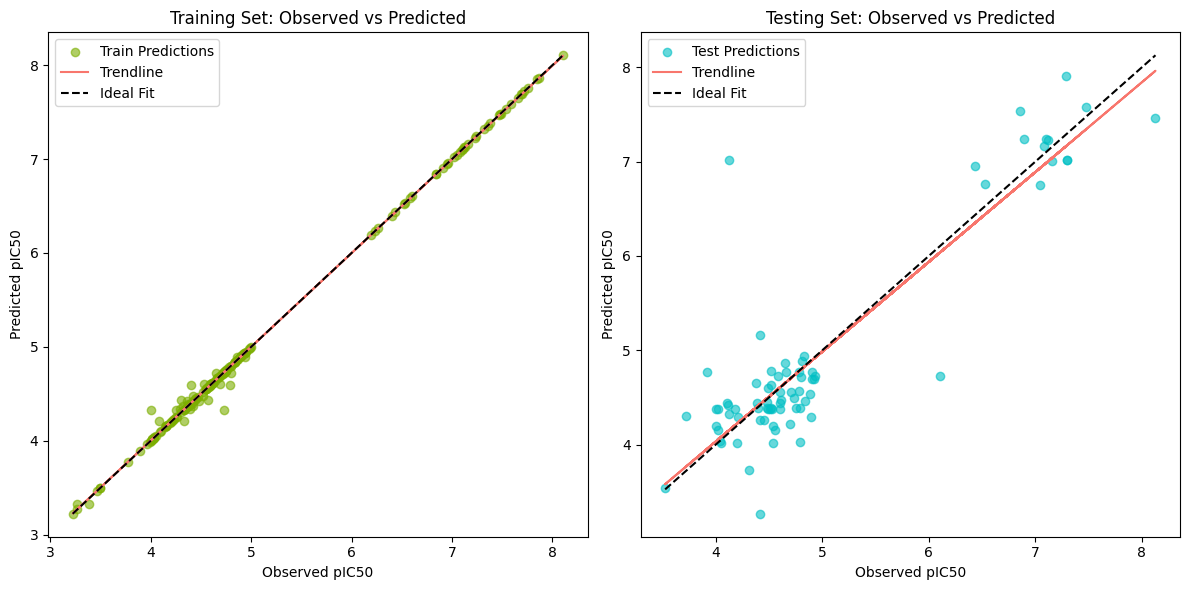

In [ ]:
# Plot True vs Predicted values for Training Set
plt.figure(figsize=(12, 6))

# Training Set
plt.subplot(1, 2, 1)
plt.scatter(Y_train, Y_train_pred, c="#7CAE00", alpha=0.6, label="Train Predictions")
z_train = np.polyfit(Y_train, Y_train_pred, 1)
p_train = np.poly1d(z_train)
plt.plot(Y_train, p_train(Y_train), "#F8766D", label="Trendline")
plt.plot([min(Y_train), max(Y_train),], [min(Y_train), max(Y_train)], "k--", label="Ideal Fit")
plt.title("Training Set: Observed vs Predicted")
plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.legend()

# Testing Set
plt.subplot(1, 2, 2)
plt.scatter(Y_test, Y_test_pred, c="#00BFC4", alpha=0.6, label="Test Predictions")
z_test = np.polyfit(Y_test, Y_test_pred, 1)
p_test = np.poly1d(z_test)
plt.plot(Y_test, p_test(Y_test), "#F8766D", label="Trendline")
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], "k--", label="Ideal Fit")
plt.title("Testing Set: Observed vs Predicted")
plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.legend()

plt.tight_layout()

# Save the plot
plt.savefig("ExtraTrees_observed_vs_predicted_plot.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# Train set results
train_results = pd.DataFrame({
    'Name': names_train,
    'Observed pIC50': Y_train,
    'Predicted pIC50': Y_train_pred,
    'Dataset': 'Train'
})

# Test set results
test_results = pd.DataFrame({
    'Name': names_test,
    'Observed pIC50': Y_test,
    'Predicted pIC50': Y_test_pred,
    'Dataset': 'Test'
})

# Combine train and test results
results = pd.concat([train_results, test_results], axis=0).reset_index(drop=True)
# Display the results
print(results)

# Save the results to a CSV file if needed
results.to_csv('Extra_Trees_VIF_Results.csv', index=False)


      Name  Observed pIC50  Predicted pIC50 Dataset
0    MB249        4.988007         4.988007   Train
1     MB43        4.591760         4.591760   Train
2    MB162        6.952025         6.952025   Train
3    MB178        7.477034         7.477034   Train
4    MB183        7.688670         7.688670   Train
..     ...             ...              ...     ...
246   MB99        4.522879         4.389254    Test
247  MB135        4.891097         4.296477    Test
248  MB344        4.000000         4.197200    Test
249  MB234        4.658170         4.768007    Test
250  MB352        4.885723         4.541229    Test

[251 rows x 4 columns]


Hyperparameter Tuning

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation score: 0.8914782932174503
Training Set Mean Squared Error: 0.0775609393525193
Training Set R²: 0.946258611874271
Testing Set Mean Squared Error: 0.17689945293838819
Testing Set R²: 0.8499835137716145


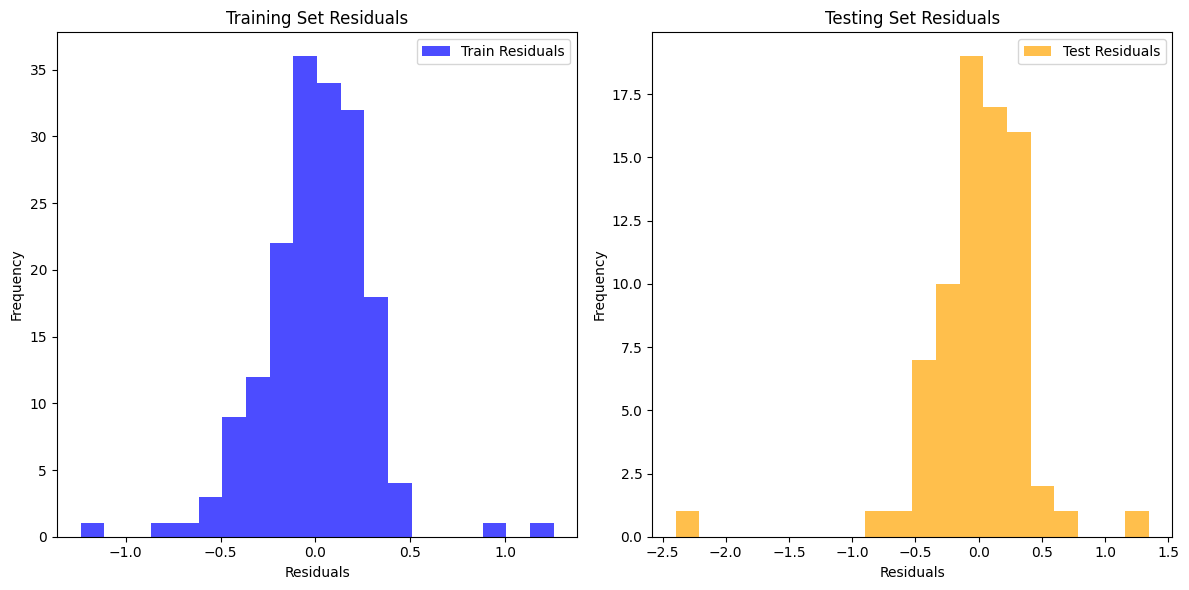

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Define ExtraTreesRegressor and parameter grid
rf = ExtraTreesRegressor(n_estimators=300, random_state=42, bootstrap=True)
param_grid = {
    'max_depth': [10, 15, 20],
    'max_features': ['sqrt', 'log2', 0.5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5, 10]
}

# Step 3: Perform GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)
grid_search_rf.fit(X_train, Y_train)

# Step 4: Evaluate the best model
best_rf = grid_search_rf.best_estimator_
Y_train_pred = best_rf.predict(X_train)
Y_test_pred = best_rf.predict(X_test)

print("Best hyperparameters:", grid_search_rf.best_params_)
print("Best cross-validation score:", grid_search_rf.best_score_)
print("Training Set Mean Squared Error:", mean_squared_error(Y_train, Y_train_pred))
print("Training Set R²:", r2_score(Y_train, Y_train_pred))
print("Testing Set Mean Squared Error:", mean_squared_error(Y_test, Y_test_pred))
print("Testing Set R²:", r2_score(Y_test, Y_test_pred))

# Step 5: Plot residuals
train_residuals = Y_train - Y_train_pred
test_residuals = Y_test - Y_test_pred

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(train_residuals, bins=20, color="blue", alpha=0.7, label="Train Residuals")
plt.title("Training Set Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(test_residuals, bins=20, color="orange", alpha=0.7, label="Test Residuals")
plt.title("Testing Set Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()


# Save the plot
plt.savefig("ExtraTrees_Trains_Residuals_vs_Test_Residual_plot.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# Combine results for training and test sets
train_results = pd.DataFrame({
    'Name': names_train,  # Replace with the actual column containing molecule names in the train set
    'Observed pIC50': Y_train,
    'Predicted pIC50': Y_train_pred,
    'Dataset': 'Train'
})

test_results = pd.DataFrame({
    'Name': names_test,  # Replace with the actual column containing molecule names in the test set
    'Observed pIC50': Y_test,
    'Predicted pIC50': Y_test_pred,
    'Dataset': 'Test'
})

# Combine train and test results
results = pd.concat([train_results, test_results], axis=0).reset_index(drop=True)
# Display the results
print(results)

# Save the results to a CSV file if needed
results.to_csv('Extra_Trees_Hyperparameter_tuned_result.csv', index=False)

      Name  Observed pIC50  Predicted pIC50 Dataset
0    MB249        4.988007         4.706901   Train
1     MB43        4.591760         4.692801   Train
2    MB162        6.952025         6.961416   Train
3    MB178        7.477034         7.319951   Train
4    MB183        7.688670         7.616733   Train
..     ...             ...              ...     ...
246   MB99        4.522879         4.307316    Test
247  MB135        4.891097         4.437045    Test
248  MB344        4.000000         4.425634    Test
249  MB234        4.658170         4.736424    Test
250  MB352        4.885723         4.500945    Test

[251 rows x 4 columns]


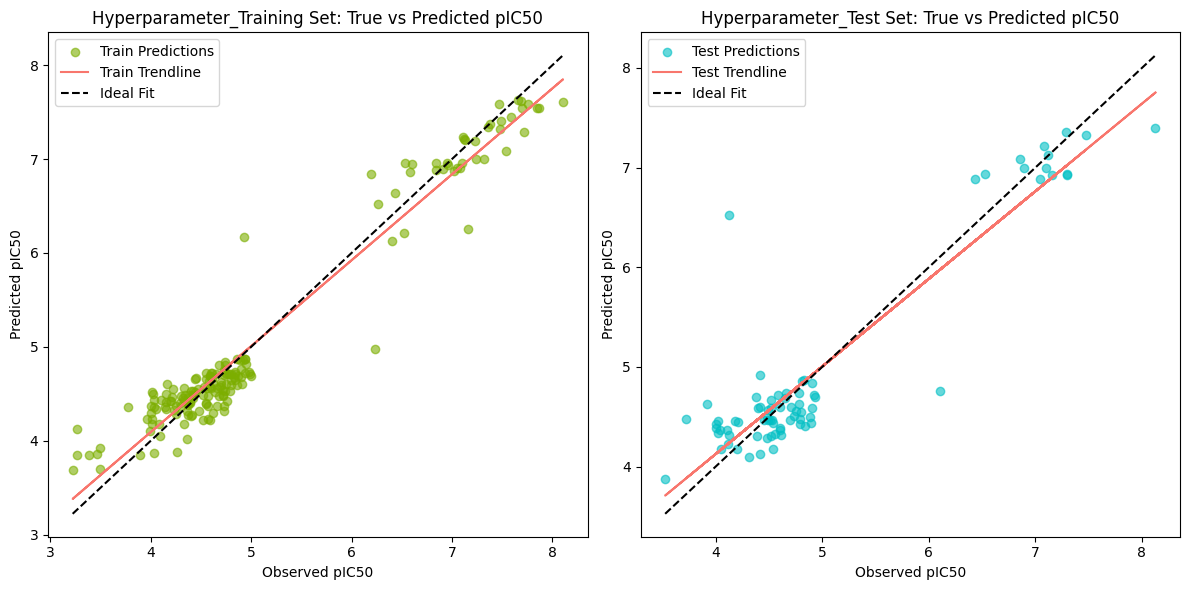

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Training set plot
plt.subplot(1, 2, 1)
plt.scatter(Y_train, Y_train_pred, c="#7CAE00", alpha=0.6, label="Train Predictions")

# Add a trendline for training set
z_train = np.polyfit(Y_train, Y_train_pred, 1)
p_train = np.poly1d(z_train)
plt.plot(Y_train, p_train(Y_train), "#F8766D", label="Train Trendline")

# Add ideal fit line
plt.plot([min(Y_train), max(Y_train)], [min(Y_train), max(Y_train)], "k--", label="Ideal Fit")
plt.title("Hyperparameter_Training Set: True vs Predicted pIC50")
plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.legend()

# Test set plot
plt.subplot(1, 2, 2)
plt.scatter(Y_test, Y_test_pred, c="#00BFC4", alpha=0.6, label="Test Predictions")

# Add a trendline for test set
z_test = np.polyfit(Y_test, Y_test_pred, 1)
p_test = np.poly1d(z_test)
plt.plot(Y_test, p_test(Y_test), "#F8766D", label="Test Trendline")

# Add ideal fit line
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], "k--", label="Ideal Fit")
plt.title("Hyperparameter_Test Set: True vs Predicted pIC50")
plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.legend()

plt.tight_layout()


# Save the plot
plt.savefig("ExtraTrees_Hyperparameter_tuned_observed_vs_predicted_plot.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import pickle

# Save the best model obtained from GridSearchCV
with open('tuned_model_ET.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Model saved successfully.")


Model saved successfully.


In [ ]:
# Load the saved model
with open('tuned_model_ET.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.ExtraTreesRegressor'>


Original Test R²: 0.8500
Mean Random R²: -0.2416
Max Random R²: 0.1561


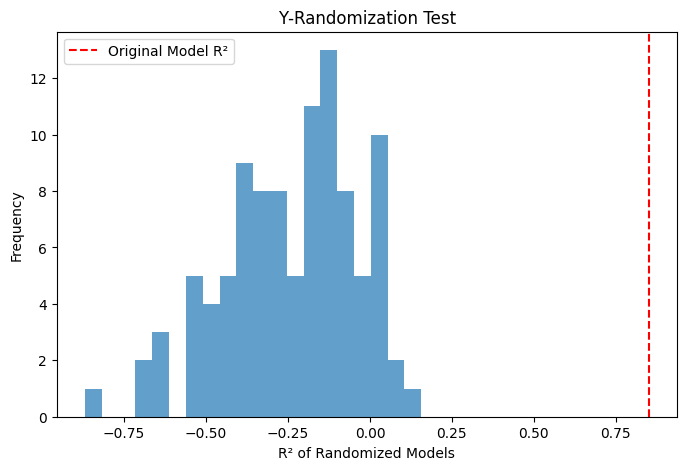

In [ ]:
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Number of randomization runs
n_iterations = 100
random_r2_scores = []

# Original R² (from your testing set)
original_r2 = r2_score(Y_test, best_rf.predict(X_test))
print(f"Original Test R²: {original_r2:.4f}")

# Y‑randomization loop
for i in range(n_iterations):
    # Shuffle training Y (scramble real relationship)
    Y_train_random = np.random.permutation(Y_train)

    # Refit model with exact same hyperparameters
    random_model = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=10,
        max_features=0.5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    random_model.fit(X_train, Y_train_random)

    # Predict on same X_test
    y_test_pred_random = random_model.predict(X_test)

    # Calculate R²
    r2_rand = r2_score(Y_test, y_test_pred_random)
    random_r2_scores.append(r2_rand)

# Print randomization results
print(f"Mean Random R²: {np.mean(random_r2_scores):.4f}")
print(f"Max Random R²: {np.max(random_r2_scores):.4f}")

# Optional: Plot distribution of random R²
plt.figure(figsize=(8, 5))
plt.hist(random_r2_scores, bins=20, alpha=0.7)
plt.axvline(original_r2, color='red', linestyle='--', label="Original Model R²")
plt.xlabel("R² of Randomized Models")
plt.ylabel("Frequency")
plt.title("Y‑Randomization Test")
plt.legend()
plt.savefig("y_randomization_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## Model Performance

In [ ]:
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_train, Y_train_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_train, Y_train_pred))

Mean squared error (MSE): 0.08
Coefficient of determination (R^2): 0.95


# Data Visualization (Experimental vs Predicted pIC50 for Training Data)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

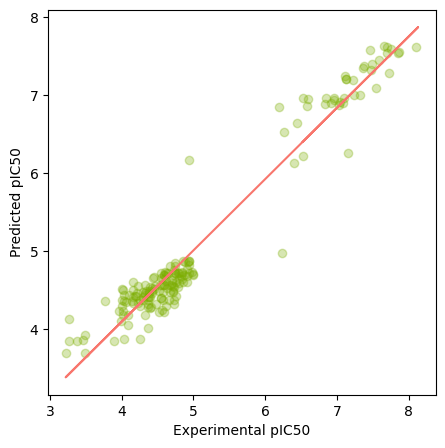

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(x=Y_train, y=Y_train_pred, c="#7CAE00", alpha=0.3)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y_train, Y_train_pred, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')
# Save the plot
plt.savefig("ExtraTrees_train_expremental_plot.png", dpi=300, bbox_inches='tight')

Outlier Compounds:
MB31 | Leverage: 0.839 | Std. Residual: -0.000
MB231 | Leverage: 0.762 | Std. Residual: 0.000
MB190 | Leverage: 0.954 | Std. Residual: -0.000
MB88 | Leverage: 0.060 | Std. Residual: -6.512
MB115 | Leverage: 0.074 | Std. Residual: 3.885
MB113 | Leverage: 0.074 | Std. Residual: -3.885
MB193 | Leverage: 0.856 | Std. Residual: 0.000
MB4 | Leverage: 0.060 | Std. Residual: 7.954
MB29 | Leverage: 0.944 | Std. Residual: -0.000


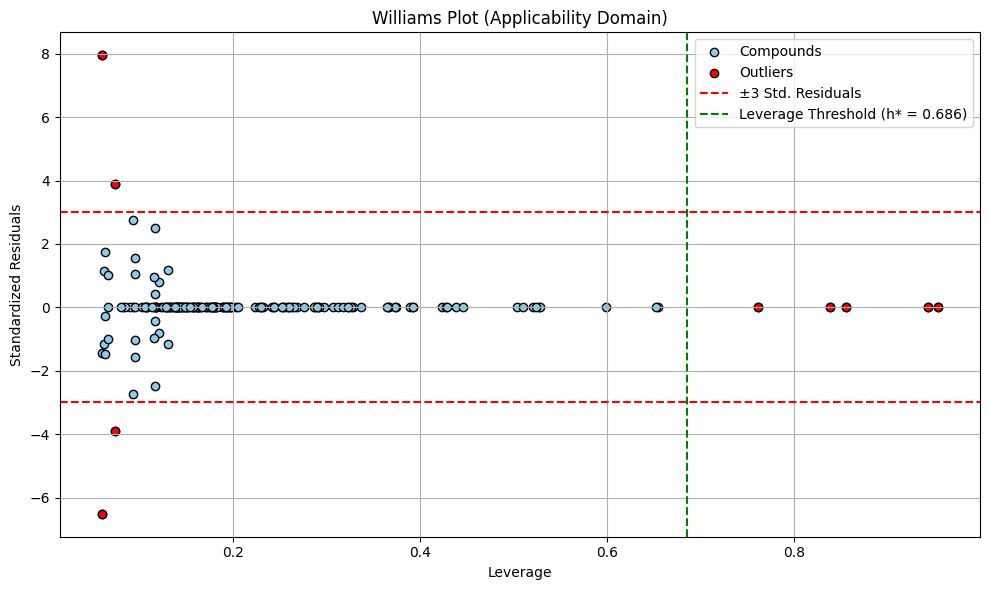

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Prepare X matrix
X_array = X_train.values if hasattr(X_train, 'values') else X_train
n, p = X_array.shape

# Step 2: Compute leverage
# Recalculate H using the correct formula
H = X_array @ np.linalg.pinv(X_array.T @ X_array) @ X_array.T
leverage = np.diag(H)


# Step 3: Predict and calculate residuals
Y_pred_train = model.predict(X_train)
Y_train_array = Y_train.values if hasattr(Y_train, 'values') else Y_train
residuals = Y_train_array - Y_pred_train

# Avoid divide-by-zero: add small epsilon
epsilon = 1e-8
mse = np.mean(residuals ** 2)
denominator = np.sqrt(mse * (1 - leverage + epsilon))
standardized_residuals = residuals / denominator

# Step 4: Leverage threshold
h_star = 3 * (p + 1) / n

# Step 5: Detect outliers
outlier_indices = np.where((np.abs(standardized_residuals) > 3) | (leverage > h_star))[0]

print("Outlier Compounds:")
outlier_data = []
for idx in outlier_indices:
    # Use names_train to get the compound name based on the index
    compound_name = names_train.iloc[idx] if idx < len(names_train) else f"Index {idx}"
    lev = leverage[idx]
    std_res = standardized_residuals.iloc[idx] if hasattr(standardized_residuals, 'iloc') else standardized_residuals[idx]
    print(f"{compound_name} | Leverage: {lev:.3f} | Std. Residual: {std_res:.3f}")
    outlier_data.append({
        "Compound_Name": compound_name,
        "Leverage": lev,
        "Standardized_Residual": std_res
    })

# Optional: Save to CSV
import pandas as pd
outliers_df = pd.DataFrame(outlier_data)
outliers_df.to_csv("Outlier_Compounds.csv", index=False)

# Step 6: Plot Williams Plot
plt.figure(figsize=(10, 6))
plt.scatter(leverage, standardized_residuals, edgecolors='k', facecolors='skyblue', label="Compounds")

# Highlight outliers in red
if len(outlier_indices) > 0:
    plt.scatter(leverage[outlier_indices],
                standardized_residuals.iloc[outlier_indices] if hasattr(standardized_residuals, 'iloc') else standardized_residuals[outlier_indices],
                color='red', edgecolors='k', label='Outliers')

plt.axhline(y=3, color='red', linestyle='--', label='±3 Std. Residuals')
plt.axhline(y=-3, color='red', linestyle='--')
plt.axvline(x=h_star, color='green', linestyle='--', label=f'Leverage Threshold (h* = {h_star:.3f})')

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot (Applicability Domain)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("ExtraTrees_Williams_plot.png", dpi=300, bbox_inches='tight')
plt.show()